In [43]:
import os 
import shutil as sh 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import plotly . express as px 
import seaborn as sns 
import random 


In [ ]:
path = "D:\\personal related\\codes\\vs code\\jupyter\\new start\\data sets\\cat and dog\\PetImages"
n_cats = len(os . listdir(os . path .join (path , "Cat")))
n_dogs = len(os . listdir (os . path . join (path , "Dog")))
print([n_cats , n_dogs])

 we have 12.5 k cat and dog images 

## lets create the required file tree structure ##

In [ ]:
original_dataset_dir = r"D:\personal related\codes\vs code\jupyter\new start\data sets\cat and dog\PetImages"
base_dir = original_dataset_dir
org_categories = ["Cat" , "Dog"]
new_cats = ["cats" , "dogs"]
folders = ["train" , "validation" , "test"]
for split in folders : 
    for cat in new_cats : 
        os.makedirs(os.path.join (base_dir , split , cat ) , exist_ok = True )
# now that we have created the required folder structure in the above code lets move the files into them after splitting the data 
def split_data (files , train_split = 0.75 , val_split = 0.15 ): # and the remaining data goes to testing  
    random . shuffle (files )
    count = len(files )
    train_end = int(count * train_split)
    val_end = int(count * (train_split + val_split))
    return files[:train_end ] , files [train_end : val_end] , files [val_end : ]
cat_train , cat_validation , cat_test = split_data (os.listdir (os.path.join (base_dir , "Cat")))
dog_train , dog_validation , dog_test = split_data (os.listdir (os.path.join (base_dir , "Dog")))
# now we need to copy the files of train , validatin and test into their respective folders 

for file in cat_train : 
    sh . move ( os.path.join(base_dir , "Cat" , file), os.path.join (base_dir , "train" , "cats"))
for file in cat_validation : 
    sh . move ( os.path.join(base_dir , "Cat" , file) , os.path.join (base_dir , "validation" , "cats"))
for file in cat_test  : 
    sh . move ( os.path.join(base_dir , "Cat" , file) , os.path.join (base_dir , "test" , "cats"))
for file in dog_train  : 
    sh . move ( os.path.join(base_dir , "Dog" , file) , os.path.join (base_dir , "train" , "dogs"))    
for file in dog_validation : 
    sh . move ( os.path.join(base_dir , "Dog" , file) , os.path.join (base_dir , "validation" , "dogs"))
for file in dog_test : 
    sh . move ( os.path.join(base_dir , "Dog" , file), os.path.join (base_dir , "test" , "dogs"))


1 Data Cleaning 

2 Preprocessing

3 Data Augmentaion

4 Load Data into Model

5 Build the CNN model

6 Compile the Model 

7 Train the Model

8 Moniter the Model
 
9 Make Predictions and Improve the model 


In [ ]:
# data cleaning 
# removing all the corrupt images in the data set 
from PIL import Image 
for folder in os.listdir(base_dir): 
    for category in os.listdir (os.path.join (base_dir , folder )) : 
        for file in os . listdir (os.path.join (base_dir , folder , category)) : 
            file_path = os.path . join (base_dir , folder , category , file )
            try:
                img = Image.open(file_path)
                img.verify()   # checks if the image is broken
            except:
                print("Removing corrupted file:", file_path)
                os.remove(file_path)
# please skip the verification step as it takes so much time(nearly 2 hours) to open all the files and check them one by one , simply check the extention of the file and remove the file is its not jpg , jpeg , png which takes exponentially less time  

In [44]:
original_dataset_dir = r"D:\personal related\codes\vs code\jupyter\new start\data sets\cat and dog\PetImages"
base_dir = original_dataset_dir

In [45]:
# data preprocessing and data augmentation 

from tensorflow import keras 

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [46]:
# Training (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & Test (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    base_dir + "/train",
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

validation_data = test_datagen.flow_from_directory(
    base_dir + "/validation",
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    base_dir + "/test",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False  
)

Found 18703 images belonging to 2 classes.
Found 3750 images belonging to 2 classes.
Found 2501 images belonging to 2 classes.


In [47]:
train_data 

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

c:\Users\udayb\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [10]:
stats = model . fit (train_data , epochs = 5 , validation_data = validation_data)

Epoch 1/5
318/585 ━━━━━━━━━━━━━━━━━━━━ 3:40 827ms/step - accuracy: 0.5246 - loss: 0.8380

c:\Users\udayb\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


585/585 ━━━━━━━━━━━━━━━━━━━━ 604s 1s/step - accuracy: 0.5920 - loss: 0.6820 - val_accuracy: 0.6619 - val_loss: 0.6297
Epoch 2/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 294s 502ms/step - accuracy: 0.6760 - loss: 0.5995 - val_accuracy: 0.7416 - val_loss: 0.5272
Epoch 3/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 242s 413ms/step - accuracy: 0.7359 - loss: 0.5223 - val_accuracy: 0.7747 - val_loss: 0.4639
Epoch 4/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 267s 456ms/step - accuracy: 0.7730 - loss: 0.4725 - val_accuracy: 0.8032 - val_loss: 0.4209
Epoch 5/5
585/585 ━━━━━━━━━━━━━━━━━━━━ 373s 543ms/step - accuracy: 0.8005 - loss: 0.4293 - val_accuracy: 0.8219 - val_loss: 0.3984


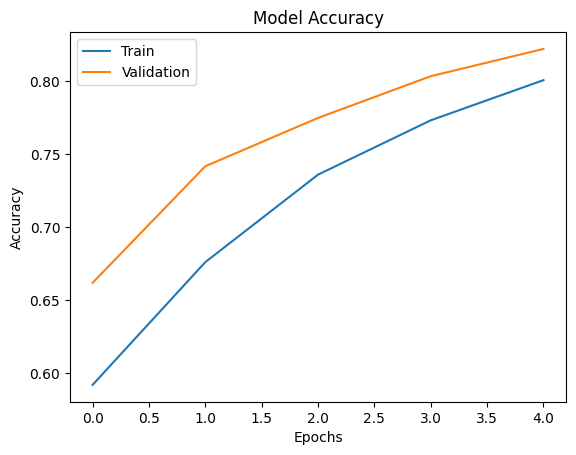

In [11]:
import matplotlib.pyplot as plt

plt.plot(stats.history['accuracy'])
plt.plot(stats.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

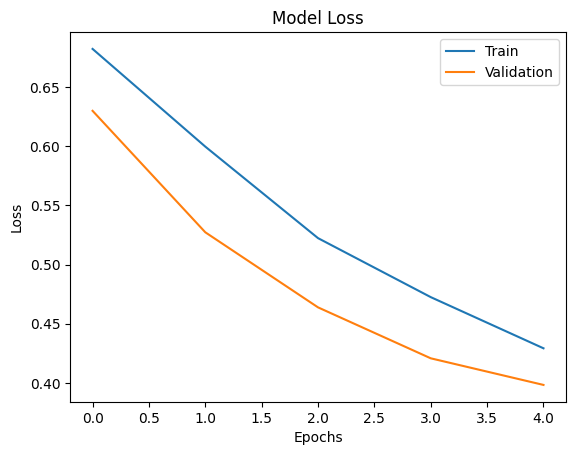

In [12]:
plt.plot(stats.history['loss'])
plt.plot(stats.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [28]:
test_data.reset()

predictions = model.predict(test_data, verbose=1)
predicted_classes = (predictions > 0.6).astype(int)

true_labels = test_data.classes
class_labels = {v:k for k,v in test_data.class_indices.items()}

wrong_indices = np.where(predicted_classes.flatten() != true_labels)[0]

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step


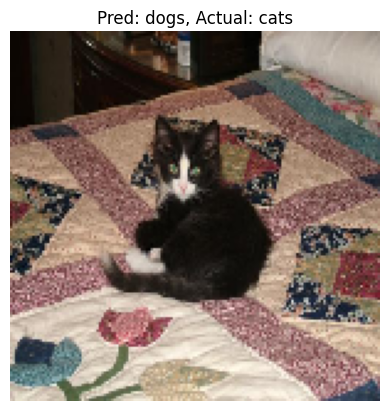

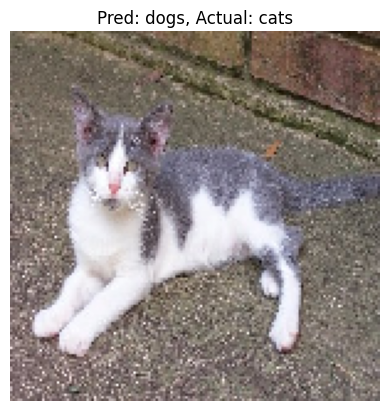

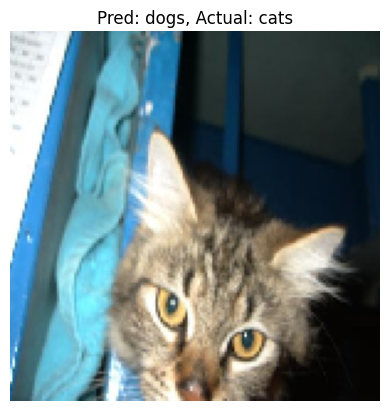

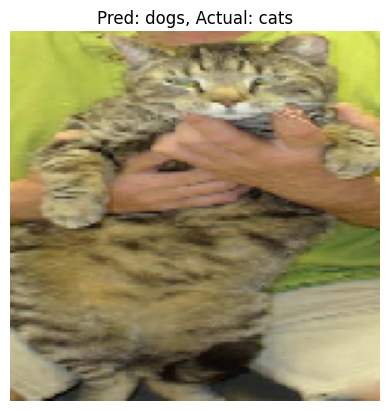

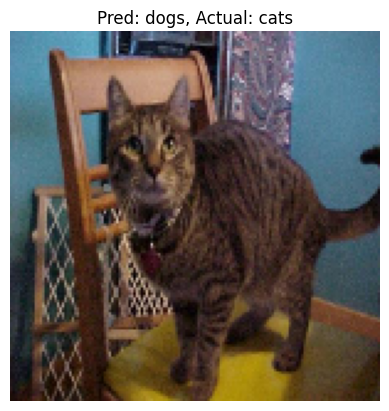

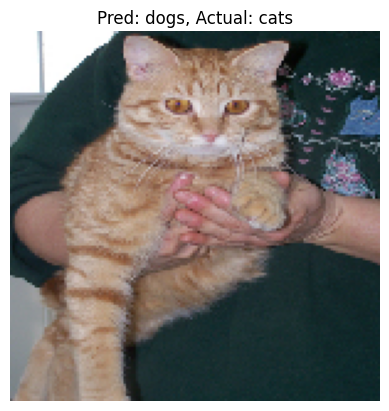

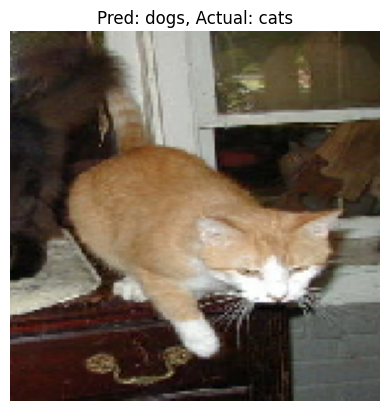

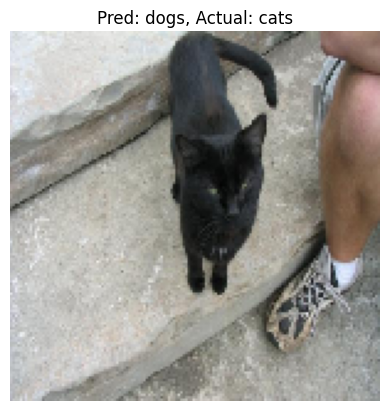

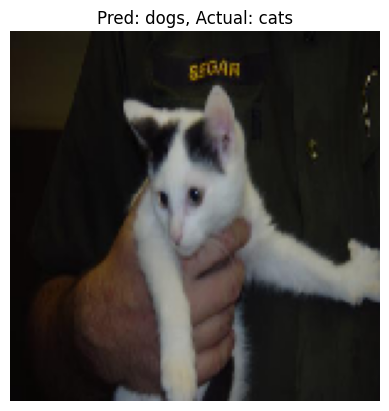

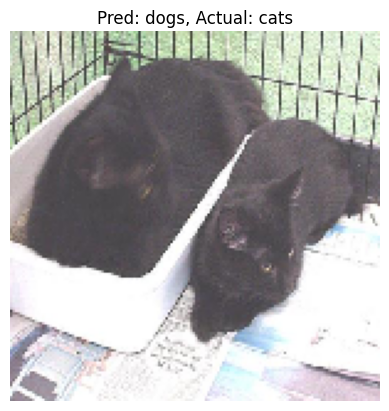

In [29]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

file_paths = test_data.filepaths

for i in wrong_indices[:10]:
    img = image.load_img(file_paths[i], target_size=(150,150))
    img_array = image.img_to_array(img) / 255.0

    plt.imshow(img_array)  
    plt.title(f"Pred: {class_labels[predicted_classes[i][0]]}, Actual: {class_labels[true_labels[i]]}")
    plt.axis('off')
    plt.show()

In [31]:
dog = 0 
cat = 0 
for i in predicted_classes : 
    if i == 1 : 
        dog +=1 
    else : 
        cat += 1
print(dog , cat )     

1323 1178


In [32]:
print(np.bincount(train_data.classes))

[9330 9373]


In [33]:
print(predictions[:20])

[[0.18736503]
 [0.4468949 ]
 [0.25135592]
 [0.2587888 ]
 [0.04237719]
 [0.6768769 ]
 [0.45133618]
 [0.06269337]
 [0.35456508]
 [0.9462964 ]
 [0.88927436]
 [0.352819  ]
 [0.18211421]
 [0.01417049]
 [0.9709306 ]
 [0.05407584]
 [0.5704824 ]
 [0.44769466]
 [0.5128449 ]
 [0.81078804]]


as you can see there is no fault in the data (both training as well as in testing) 

if we observe carefully all the predictions that has gone wrong is cats classified as dogs the main reason behind that is the model is confident about the image being a dog and 

is not sure its a cat so if we observe the probabilities of the predictions in the above output we can see that the cats fall in the prob like around 0.5 

Solution 

train the model more (increase the epochs)

slightly tweak the border condition (prob > 0.5 ---> dogs else cats) make that 0.5 to 0.55 

[[ 993  257]
 [ 185 1066]]


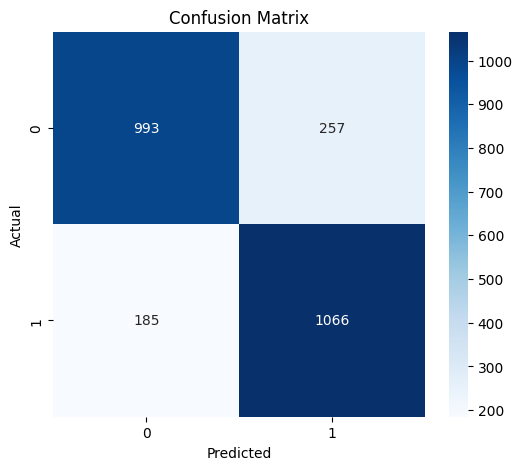

In [36]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_labels, predicted_classes)
print(cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Finetuning the model ##

In [40]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)
train_data = train_datagen.flow_from_directory(
    base_dir + "/train",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

validation_data = test_datagen.flow_from_directory(
    base_dir + "/validation",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    base_dir + "/test" ,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False   
)

Found 18703 images belonging to 2 classes.
Found 3750 images belonging to 2 classes.
Found 2501 images belonging to 2 classes.


In [50]:
# added the dropout layer for more generalisation 
from tensorflow.keras import layers, models
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))


model.add(layers.Dropout(0.5))  


model.add(layers.Dense(1, activation='sigmoid'))

In [52]:
# lets set a laerning rate for the model 
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.0001),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [53]:
stats = model . fit (train_data , epochs = 15 , validation_data = validation_data)

Epoch 1/15
310/585 ━━━━━━━━━━━━━━━━━━━━ 6:32 1s/step - accuracy: 0.5727 - loss: 0.7005

c:\Users\udayb\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


585/585 ━━━━━━━━━━━━━━━━━━━━ 1041s 2s/step - accuracy: 0.6463 - loss: 0.6292 - val_accuracy: 0.7333 - val_loss: 0.5476
Epoch 2/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 668s 1s/step - accuracy: 0.7156 - loss: 0.5578 - val_accuracy: 0.7483 - val_loss: 0.5177
Epoch 3/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 598s 1s/step - accuracy: 0.7438 - loss: 0.5205 - val_accuracy: 0.7669 - val_loss: 0.4827
Epoch 4/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 867s 1s/step - accuracy: 0.7526 - loss: 0.4997 - val_accuracy: 0.7763 - val_loss: 0.4625
Epoch 5/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 1084s 2s/step - accuracy: 0.7630 - loss: 0.4831 - val_accuracy: 0.7872 - val_loss: 0.4494
Epoch 6/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 448s 763ms/step - accuracy: 0.7740 - loss: 0.4744 - val_accuracy: 0.7944 - val_loss: 0.4393
Epoch 7/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 284s 486ms/step - accuracy: 0.7834 - loss: 0.4590 - val_accuracy: 0.7963 - val_loss: 0.4335
Epoch 8/15
585/585 ━━━━━━━━━━━━━━━━━━━━ 326s 557ms/step - accuracy: 0.7890 - loss: 0.4478 - val_accu

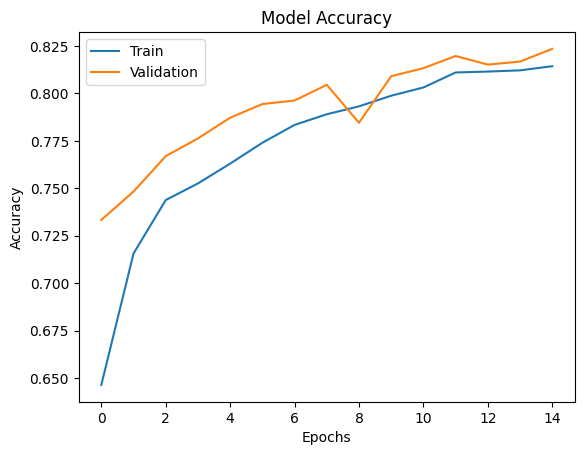

In [57]:
import matplotlib.pyplot as plt

plt.plot(stats.history['accuracy'])
plt.plot(stats.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

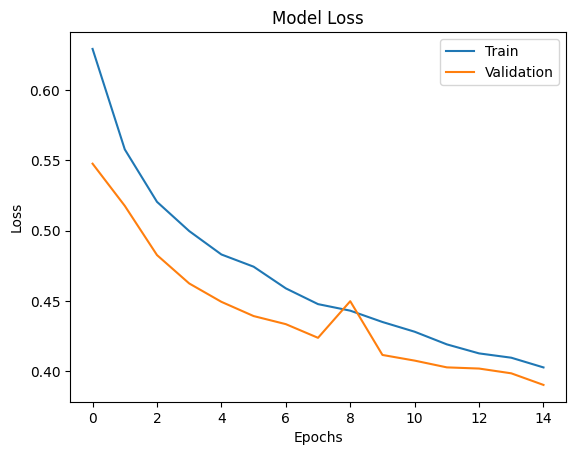

In [58]:
plt.plot(stats.history['loss'])
plt.plot(stats.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

[[ 993  257]
 [ 185 1066]]


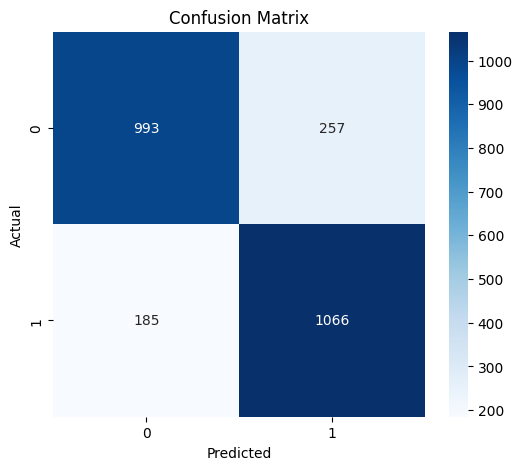

In [59]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_labels, predicted_classes)
print(cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()